# ENGR 418 Project Stage 1


## Group 5


Jason Schultz - 24662652


Matthew Hinchliff - 97352314

In [12]:
'''
Sets up all library dependencies as well as sets up filepaths of data.
Also defines a function to read in images for training and testing.
'''

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix)
from PIL import Image

filepath = "../project/Lego_dataset_1"
folder_training = filepath + "/training/"
folder_testing = filepath + "/testing/"

def get_data(folder: str, im_width: int, label: str, label_index: int, n_samples: int):
    file_names = os.listdir(folder)
    label_files = []
    for file in file_names:
        if file.startswith(label):
            label_files.append(file)

    x = np.empty((len(label_files), im_width**2))
    y = np.empty((len(label_files), 1))

    if n_samples > len(label_files):
        i_max = len(label_files)
    else:
        i_max = n_samples

    for i in range(i_max):
        path = folder + label_files[i]
        im = Image.open(path).convert("L")  # convert to greyscale
        im = im.resize((im_width, im_width))
        im_array = np.asarray(im)
        x[i:] = im_array.reshape(1, -1)
        y[i, 0] = label_index

    return x, y

(144, 4096) (144, 1)


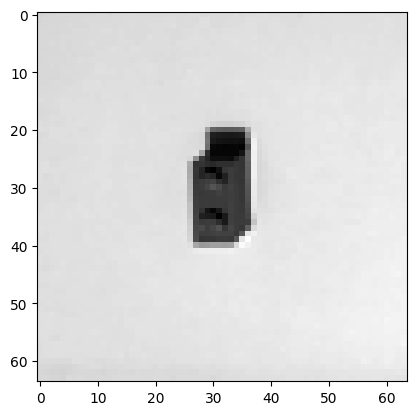

In [13]:
'''

'''

# Number of pixels used for square images
im_width = 64  # Max allowed is 64
labels = ["2b1", "cir", "rec", "squ"]
P_c = 100
# x_train = np.empty((P_c*len(labels), im_width**2))
# y_train = np.empty((P_c*len(labels), 1))
x_train_list = []
y_train_list = []

for (i, label) in enumerate(labels):
    x_i, y_i = get_data(folder_training, im_width, label, i, P_c)
    x_train_list.append(x_i)
    y_train_list.append(y_i)

x_train = np.array(x_train_list[0])
y_train = np.array(y_train_list[0])
for i in range(1, len(x_train_list)):
    x_train = np.append(x_train, x_train_list[i], axis = 0)
    y_train = np.append(y_train, y_train_list[i], axis = 0)
print(x_train.shape, y_train.shape)

# Choosing to show an image of a number by changing the row number.
# Each set of 1000 will contain one digit.
plt.imshow(x_train[20,:].reshape(im_width, im_width), cmap = "gray")

/home/jason/coding_projects/python/engr418/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(4, 4096)
(72, 4096) (72, 1)
[[18  0  0  0]
 [ 0 17  0  1]
 [ 0  0 17  1]
 [ 0  1  0 17]]
0.9583333333333334


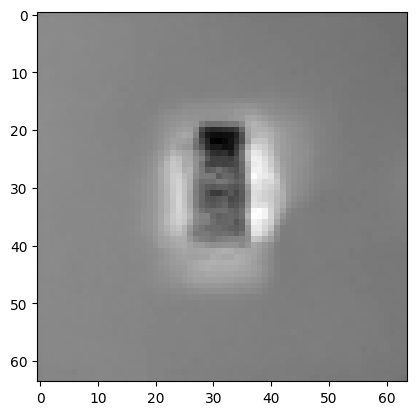

In [14]:
'''

'''

model = LogisticRegression(max_iter = 500)
model.fit(x_train, y_train)

print(model.coef_.shape)
plt.imshow(model.coef_[0,:].reshape(im_width, im_width), cmap = "gray")

x_test_list = []
y_test_list = []

for (i, label) in enumerate(labels):
    x_i, y_i = get_data(folder_testing, im_width, label, i, P_c)
    x_test_list.append(x_i)
    y_test_list.append(y_i)

x_test = np.array(x_test_list[0])
y_test = np.array(y_test_list[0])
for i in range(1, len(x_test_list)):
    x_test = np.append(x_test, x_test_list[i], axis = 0)
    y_test = np.append(y_test, y_test_list[i], axis = 0)
print(x_test.shape, y_test.shape)

y_pred = model.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))